In [2]:
import pandas as pd
import numpy as np
df = pd.read_csv("../data/NVDA.csv")
df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,0.199652,0.201027,0.184294,0.184982,497124000
1,2009-01-05,0.203319,0.207904,0.195984,0.197360,705736000
2,2009-01-06,0.210196,0.216156,0.204695,0.209279,657904000
3,2009-01-07,0.197589,0.205382,0.190483,0.205382,870096000
4,2009-01-08,0.192546,0.195067,0.180626,0.195067,1014496000


In [3]:
df['Date'] = pd.to_datetime(df['Date'])

df = df.sort_values('Date')

df = df.dropna()

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    3774 non-null   datetime64[us]
 1   Close   3774 non-null   float64       
 2   High    3774 non-null   float64       
 3   Low     3774 non-null   float64       
 4   Open    3774 non-null   float64       
 5   Volume  3774 non-null   int64         
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 177.0 KB


In [5]:
df.describe()

,Date,Close,High,Low,Open,Volume
count,3774,3774.000000,3774.000000,3774.000000,3774.000000,3.774000e+03
mean,2016-07-01 03:40:32.432432,6.796822,6.915713,6.666721,6.793541,5.230753e+08
min,2009-01-02 00:00:00,0.165269,0.171228,0.162289,0.165269,4.564400e+07
25%,2012-09-28 18:00:00,0.357397,0.362422,0.351743,0.357017,3.188510e+08
50%,2016-06-30 12:00:00,1.167304,1.176017,1.157976,1.166935,4.495585e+08
75%,2020-03-31 18:00:00,7.018725,7.091671,6.849259,6.939958,6.419770e+08
max,2023-12-29 00:00:00,50.379307,50.518225,49.387239,50.182284,3.692928e+09
std,NaN,10.659754,10.843532,10.461388,10.659140,3.205760e+08


In [6]:
# moving average
#SMA
df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['SMA_50'] = df['Close'].rolling(window=50).mean()
#EMA
df['EMA_20'] = df['Close'].ewm(span=20, adjust=False).mean()


In [7]:
# RSI
import ta

df['RSI'] = ta.momentum.RSIIndicator(df['Close'], window=14).rsi()

In [8]:
# MACD
macd = ta.trend.MACD(df['Close'])

df['MACD'] = macd.macd()
df['MACD_signal'] = macd.macd_signal()

Visualization

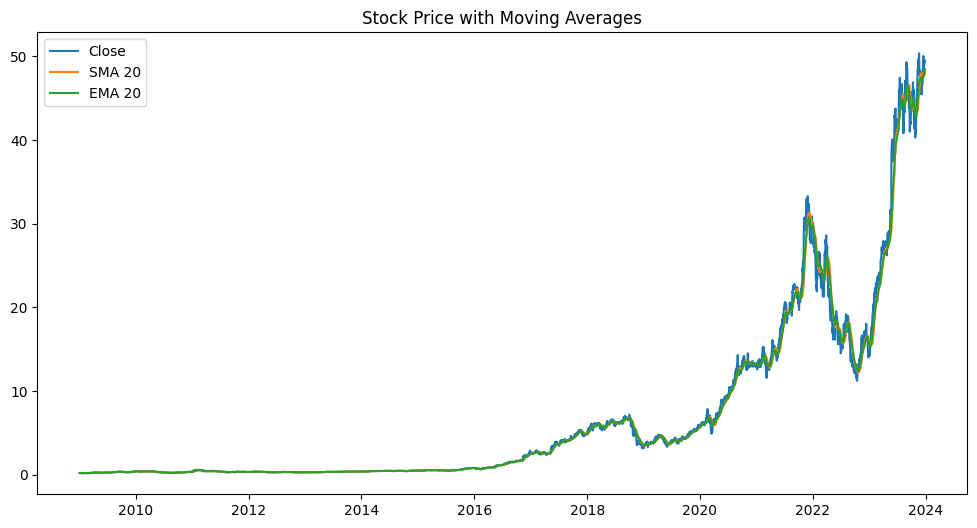

In [9]:
# Price and moving average

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(df['Date'], df['Close'], label='Close')
plt.plot(df['Date'], df['SMA_20'], label='SMA 20')
plt.plot(df['Date'], df['EMA_20'], label='EMA 20')

plt.legend()
plt.title("Stock Price with Moving Averages")
plt.show()

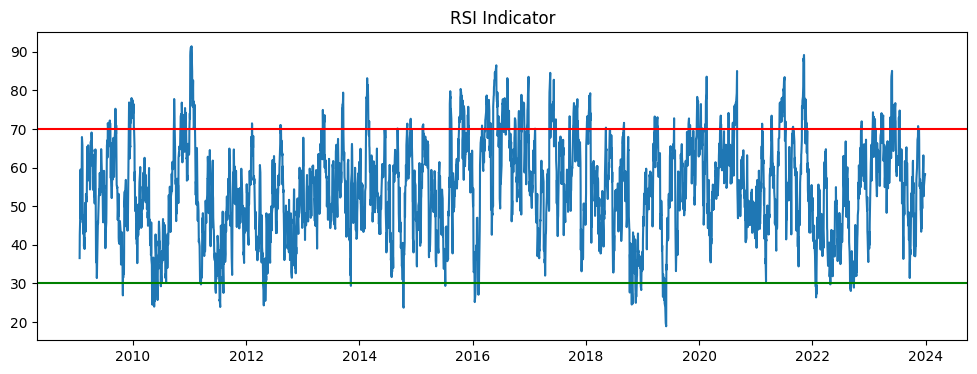

In [10]:
# RSI plot 
plt.figure(figsize=(12,4))

plt.plot(df['Date'], df['RSI'])

plt.axhline(70, color='red')
plt.axhline(30, color='green')

plt.title("RSI Indicator")
plt.show()

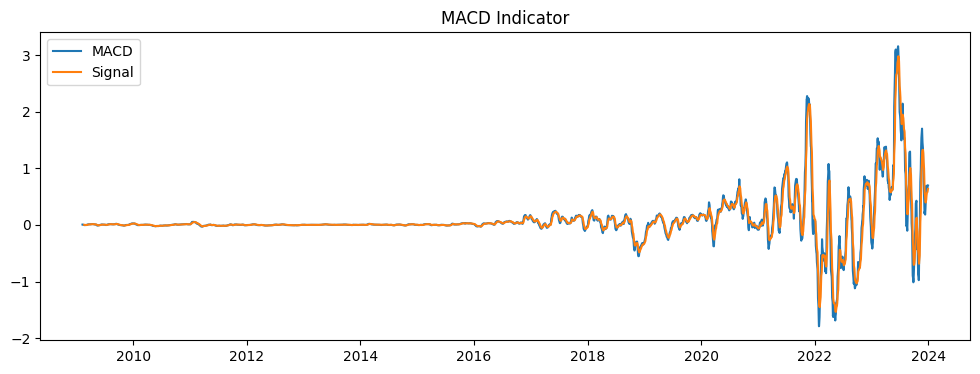

In [11]:
# MACD Plot
plt.figure(figsize=(12,4))

plt.plot(df['Date'], df['MACD'], label='MACD')
plt.plot(df['Date'], df['MACD_signal'], label='Signal')

plt.legend()
plt.title("MACD Indicator")
plt.show()

PyNance was intended to be used for financial metric computation. Due to compatibility issues with pandas_datareader, equivalent financial indicators were computed manually using pandas and numpy. These include daily returns, rolling volatility (20-day window), log returns, and drawdown, which are standard outputs consistent with PyNance financial analysis functionality.

In [12]:

df['returns'] = df['Close'].pct_change()
df['volatility'] = df['returns'].rolling(20).std()
df['log_returns'] = np.log(df['Close'] / df['Close'].shift(1))

In [13]:
df.tail()

,Date,Close,High,Low,Open,Volume,SMA_20,SMA_50,EMA_20,RSI,MACD,MACD_signal,returns,volatility,log_returns
3769,2023-12-22,48.805527,49.358247,48.442706,49.170342,252507000,47.706983,46.257777,48.024644,55.352119,0.634352,0.564438,-0.003266,0.018823,-0.003271
3770,2023-12-26,49.254299,49.575137,48.935459,48.943454,244200000,47.759019,46.334178,48.141754,57.245971,0.655689,0.582688,0.009195,0.018810,0.009153
3771,2023-12-27,49.392231,49.655100,49.060397,49.486186,233648000,47.838989,46.400666,48.260847,57.837928,0.675937,0.601338,0.002800,0.018665,0.002796
3772,2023-12-28,49.497185,49.859003,49.387239,49.618126,246587000,47.908266,46.512367,48.378593,58.310919,0.692470,0.619564,0.002125,0.018630,0.002123
3773,2023-12-29,49.497185,49.971949,48.726571,49.788039,389293000,48.046003,46.658888,48.485126,58.310919,0.697532,0.635158,0.000000,0.017250,0.000000


In [14]:
df.to_csv("../data/NVDA_processed.csv")